In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

DB = '../data/humans_clean.sqlite3'
MIN_SCIENTISTS_PER_BIN = 5

# Load the set of occupation names classified as "scientist" in the database
conn = sqlite3.connect(DB)
_cur = conn.execute("SELECT DISTINCT lower(name_en) FROM occupations WHERE meta_occupation = 'scientist'")
SCIENTIFIC_OCCUPATIONS = set(row[0] for row in _cur.fetchall())
conn.close()

print(f'Loaded {len(SCIENTIFIC_OCCUPATIONS)} scientific occupation labels')

Loaded 1729 scientific occupation labels


In [2]:
# ── Evolution of science: number of individuals with at least one scientific occupation ──
# Polities and regions spanning different eras and geographies.

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

evo_results = []

# --- Polity-based queries ---
polity_queries = [
    ('Greek City-States', "c.polity_name LIKE 'Greek City-States%'"),
    ('Kingdom of England', "c.polity_name LIKE '%Kingdom of England%'"),
]

for title, where in polity_queries:
    cur = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year)
        FROM consolidate c
        WHERE {where} AND c.impact_year IS NOT NULL
    ''')
    yr_start, yr_end = cur.fetchone()

    cur = conn.execute(f'''
        SELECT c.impact_year
        FROM consolidate c
        WHERE {where}
          AND c.impact_year IS NOT NULL
          AND c.is_scientist = 1
    ''')

    bin_n = defaultdict(int)
    for (year,) in cur:
        t = ((year + 25) // 50) * 50
        bin_n[t] += 1

    complete_bins = sorted(b for b in bin_n
                           if b - 25 >= yr_start and b + 24 <= yr_end)
    counts = [bin_n[b] for b in complete_bins]

    total_sci = sum(counts)
    print(f'{title} ({yr_start}\u2013{yr_end}): {total_sci} scientists, {len(complete_bins)} bins')

    evo_results.append({
        'title': title,
        'yr_start': yr_start,
        'yr_end': yr_end,
        'bins': complete_bins,
        'counts': counts,
    })

# --- Region-based queries ---
region_queries = [
    ('Chinese World', "ir.region = 'Chinese World'", None, 1850),
    ('Muslim World',  "ir.region LIKE 'Arabic world%' OR ir.region LIKE 'Persian World%'", 700, 1850),
]

for title, region_where, clip_start, clip_end in region_queries:
    cur = conn.execute(f'''
        SELECT MIN(ir.impact_year), MAX(ir.impact_year)
        FROM individuals_regions ir
        WHERE ({region_where}) AND ir.impact_year IS NOT NULL
    ''')
    yr_start, yr_end = cur.fetchone()

    cur = conn.execute(f'''
        SELECT sub.impact_year
        FROM (
            SELECT DISTINCT ir.wikidata_id, ir.impact_year
            FROM individuals_regions ir
            WHERE ({region_where}) AND ir.impact_year IS NOT NULL
        ) sub
        WHERE EXISTS (
            SELECT 1 FROM consolidate c
            WHERE c.wikidata_id = sub.wikidata_id AND c.is_scientist = 1
        )
    ''')

    bin_n = defaultdict(int)
    for (year,) in cur:
        t = ((year + 25) // 50) * 50
        bin_n[t] += 1

    complete_bins = sorted(b for b in bin_n
                           if b - 25 >= yr_start and b + 24 <= yr_end)
    counts = [bin_n[b] for b in complete_bins]

    # Clip to requested range
    if clip_start is not None or clip_end is not None:
        filtered = [(b, c) for b, c in zip(complete_bins, counts)
                     if (clip_start is None or b >= clip_start)
                     and (clip_end is None or b <= clip_end)]
        complete_bins = [b for b, _ in filtered]
        counts = [c for _, c in filtered]
        # Update display range
        if clip_start is not None:
            yr_start = clip_start
        if clip_end is not None:
            yr_end = clip_end

    total_sci = sum(counts)
    print(f'{title} ({yr_start}\u2013{yr_end}): {total_sci} scientists, {len(complete_bins)} bins')

    evo_results.append({
        'title': title,
        'yr_start': yr_start,
        'yr_end': yr_end,
        'bins': complete_bins,
        'counts': counts,
    })

conn.close()

Greek City-States (-800–-65): 76 scientists, 12 bins


Kingdom of England (936–1708): 968 scientists, 14 bins


Chinese World (-2200–1850): 1067 scientists, 50 bins


Muslim World (700–1850): 1750 scientists, 24 bins


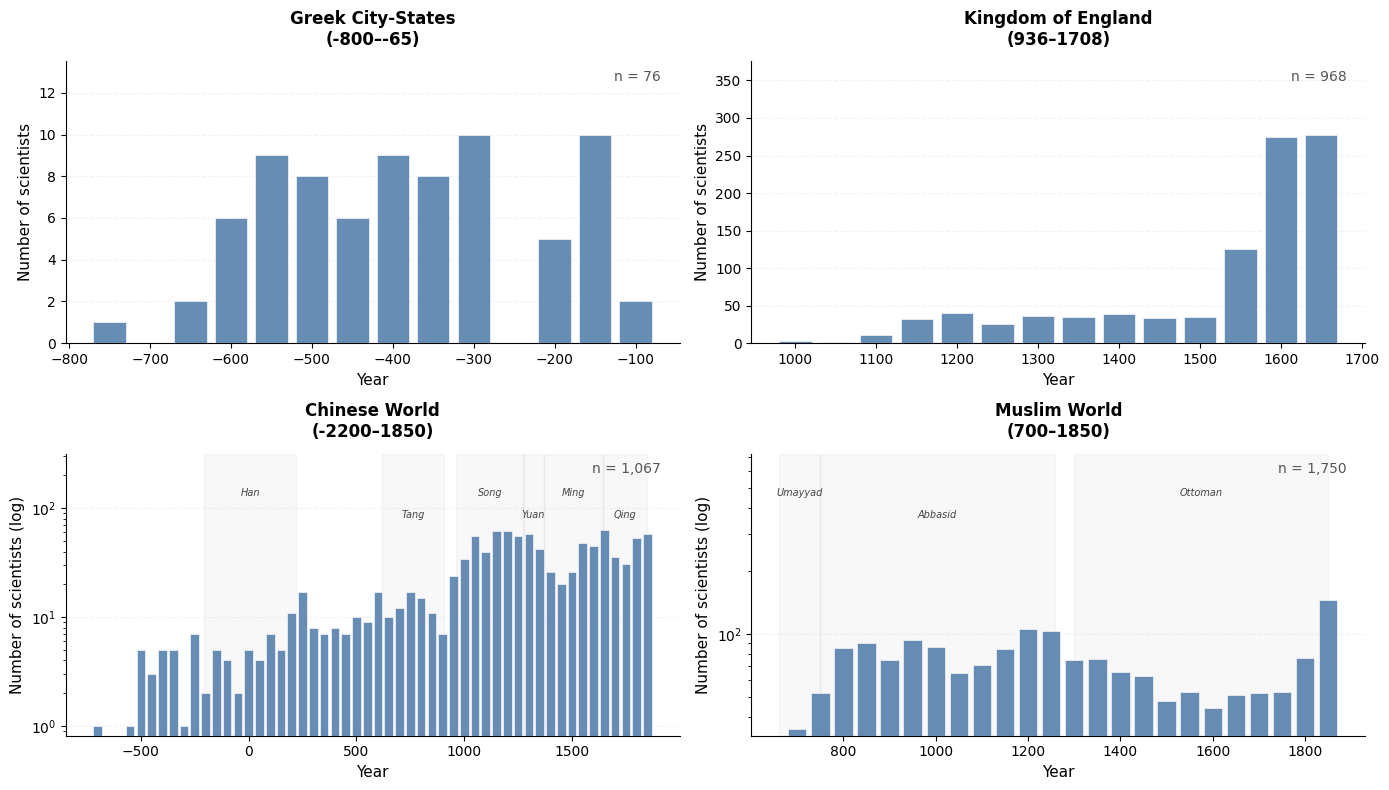

In [3]:
# ── Figure: Evolution of science across four polities/regions ──

import matplotlib.transforms as mtransforms

CHINESE_DYNASTIES = [
    ('Han', -206, 220),
    ('Tang', 618, 907),
    ('Song', 960, 1279),
    ('Yuan', 1271, 1368),
    ('Ming', 1368, 1644),
    ('Qing', 1644, 1850),
]

MUSLIM_PERIODS = [
    ('Umayyad', 661, 750),
    ('Abbasid', 750, 1258),
    ('Ottoman', 1299, 1850),
]

COLOR_BAR = '#4e79a7'

# Panels that should use log y-axis
LOG_PANELS = {'Chinese World', 'Muslim World'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, res in enumerate(evo_results):
    ax = axes[idx]
    bins = res['bins']
    counts = res['counts']

    ax.bar(bins, counts, width=40, color=COLOR_BAR, edgecolor='white',
           linewidth=0.5, alpha=0.85, zorder=3)

    if res['title'] in LOG_PANELS:
        ax.set_yscale('log')
        ax.set_ylabel('Number of scientists (log)', fontsize=11)
        # Add headroom so bars don't touch the top
        if counts:
            ax.set_ylim(top=max(counts) * 5)
    else:
        ax.set_ylabel('Number of scientists', fontsize=11)
        # Add 30% headroom for linear panels
        if counts:
            ax.set_ylim(top=max(counts) * 1.35)

    ax.set_xlabel('Year', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

    # Title above the axes with generous padding
    ax.set_title(f"{res['title']}\n({res['yr_start']}\u2013{res['yr_end']})",
                 fontsize=12, fontweight='bold', color='black',
                 loc='center', pad=12)

    # Annotate total — place below the title, inside top-right
    total = sum(counts)
    ax.text(0.97, 0.97, f'n = {total:,}', transform=ax.transAxes,
            fontsize=10, color='#555555', ha='right', va='top')

    # Dynasty/period annotations — place lower to avoid collision with n=
    blended = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    if res['title'] == 'Chinese World':
        for i, (name, start, end) in enumerate(CHINESE_DYNASTIES):
            clipped_end = min(end, 1850)
            ax.axvspan(start, clipped_end, alpha=0.06, color='#888', zorder=1)
            mid = (start + clipped_end) / 2
            y_pos = 0.88 if i % 2 == 0 else 0.80
            ax.text(mid, y_pos, name, transform=blended,
                    ha='center', va='top', fontsize=7, color='#444',
                    style='italic')

    elif res['title'] == 'Muslim World':
        for i, (name, start, end) in enumerate(MUSLIM_PERIODS):
            clipped_end = min(end, 1850)
            ax.axvspan(start, clipped_end, alpha=0.06, color='#888', zorder=1)
            mid = (start + clipped_end) / 2
            y_pos = 0.88 if i % 2 == 0 else 0.80
            ax.text(mid, y_pos, name, transform=blended,
                    ha='center', va='top', fontsize=7, color='#444',
                    style='italic')

plt.tight_layout()
plt.show()